# 🤖 Baustein 4 — Entscheidungsbaum (Decision Tree)

**IHK-Themen abgedeckt:** Decision Tree, Metriken (Accuracy/Precision/Recall/F1/Confusion Matrix), R², OOP, joblib

**Basis:** `analysetabelle.csv` (1.824 Krankenhäuser, 15 Spalten)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, ConfusionMatrixDisplay,
    r2_score
)
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('analysetabelle.csv', low_memory=False)
print(f'Datensatz: {df.shape}')
df.head(3)

Datensatz: (1824, 15)


,SO.QBID,total_qi,auffaellig_n,auffaellig_quote,hat_viele_Probleme,SO.Name,SO.Betten,SO.Bundesland,SO.Uni,KH.Träger,KH.Träger.Art,SO.Latitude,SO.Longitude,fortbildungsquote,aerzte_pro_bett
0,4876,19,18,0.947368,1,Park-Klinik GmbH,39,Schleswig-Holstein,0,Park-Klinik GmbH,privat,"54,326732","10,125615",1.0,0.358974
1,4878,2,2,1.000000,1,Johanniter Tagesklinik Schwarzenbek,0,Schleswig-Holstein,0,Johanniter-Krankenhaus Geesthacht GmbH,freigemeinnützig,"53,50572","10,478568",1.0,NaN
2,4879,24,17,0.708333,0,Sankt Elisabeth Krankenhaus Kiel,43,Schleswig-Holstein,0,Lubinus-Kliniken GmbH,freigemeinnützig,"54,316855","10,127381",1.0,0.800000


---
## 1️⃣ OOP — Modell-Pipeline als Klasse

In [2]:
class KrankenhausModell:
    """Wrapper-Klasse fuer den Krankenhaus-Qualitaets-Klassifikator."""

    FEATURE_COLS = ['SO.Betten', 'SO.Uni', 'fortbildungsquote', 'aerzte_pro_bett']
    TARGET_COL   = 'hat_viele_Probleme'
    TRAEGER_COL  = 'KH.Traeger.Art'   # wird enkodiert

    def __init__(self, max_depth=3, random_state=42):
        self.max_depth    = max_depth
        self.random_state = random_state
        self.model        = DecisionTreeClassifier(
            max_depth=max_depth, random_state=random_state
        )
        self.le           = LabelEncoder()   # fuer Traeger
        self.feature_names = None

    def prepare(self, df):
        """Features aufbereiten und fehlende Werte behandeln."""
        data = df.copy()

        # Träger-Spalte finden (Umlaut-robust)
        traeger_col = [c for c in data.columns if 'ger.Art' in c][0]
        data['traeger_enc'] = self.le.fit_transform(
            data[traeger_col].fillna('unbekannt')
        )

        cols = self.FEATURE_COLS + ['traeger_enc']
        X = data[cols].fillna(data[cols].median())
        y = data[self.TARGET_COL]

        self.feature_names = cols
        return X, y

    def fit(self, X_train, y_train):
        self.model.fit(X_train, y_train)
        return self

    def evaluate(self, X_test, y_test):
        y_pred = self.model.predict(X_test)
        return {
            'accuracy':  accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred),
            'recall':    recall_score(y_test, y_pred),
            'f1':        f1_score(y_test, y_pred),
            'cm':        confusion_matrix(y_test, y_pred),
            'y_pred':    y_pred
        }

    def save(self, path='modell_krankenhaus.pkl'):
        joblib.dump(self, path)
        print(f'Modell gespeichert: {path}')

    @staticmethod
    def load(path='modell_krankenhaus.pkl'):
        return joblib.load(path)

print('Klasse KrankenhausModell definiert ✓')

Klasse KrankenhausModell definiert ✓


---
## 2️⃣ Train-Test-Split & Basislinie

In [3]:
modell = KrankenhausModell(max_depth=3, random_state=42)
X, y = modell.prepare(df)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training:  {len(X_train):,} Häuser  ({len(X_train)/len(X):.0%})')
print(f'Test:      {len(X_test):,} Häuser  ({len(X_test)/len(X):.0%})')
print(f'\nFeatures: {modell.feature_names}')

# Basislinie: immer die häufigste Klasse vorhersagen
baseline = y_test.value_counts(normalize=True).max()
print(f'\nBasislinie (häufigste Klasse):  {baseline:.1%}')
print('→ Das Modell muss besser als die Basislinie sein.')

Training:  1,459 Häuser  (80%)
Test:      365 Häuser  (20%)

Features: ['SO.Betten', 'SO.Uni', 'fortbildungsquote', 'aerzte_pro_bett', 'traeger_enc']

Basislinie (häufigste Klasse):  50.7%
→ Das Modell muss besser als die Basislinie sein.


---
## 3️⃣ Decision Tree trainieren & bewerten

In [4]:
modell.fit(X_train, y_train)
ergebnis = modell.evaluate(X_test, y_test)

print('── Metriken auf Testdaten ──')
print(f"  Accuracy:  {ergebnis['accuracy']:.3f}")
print(f"  Precision: {ergebnis['precision']:.3f}  (Wie viele der 'viele Probleme'-Vorhersagen stimmen?)")
print(f"  Recall:    {ergebnis['recall']:.3f}   (Wie viele echten 'viele Probleme' wurden gefunden?)")
print(f"  F1-Score:  {ergebnis['f1']:.3f}")
print(f"  Basislinie:{baseline:.3f}")
print(f"  Verbesserung über Basislinie: {ergebnis['accuracy']-baseline:+.3f}")

# Cross-Validation
cv_scores = cross_val_score(modell.model, X, y, cv=5, scoring='accuracy')
print(f'\n  5-Fold CV Accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

── Metriken auf Testdaten ──
  Accuracy:  0.649
  Precision: 0.683  (Wie viele der 'viele Probleme'-Vorhersagen stimmen?)
  Recall:    0.539   (Wie viele echten 'viele Probleme' wurden gefunden?)
  F1-Score:  0.602
  Basislinie:0.507
  Verbesserung über Basislinie: +0.142

  5-Fold CV Accuracy: 0.604 ± 0.039


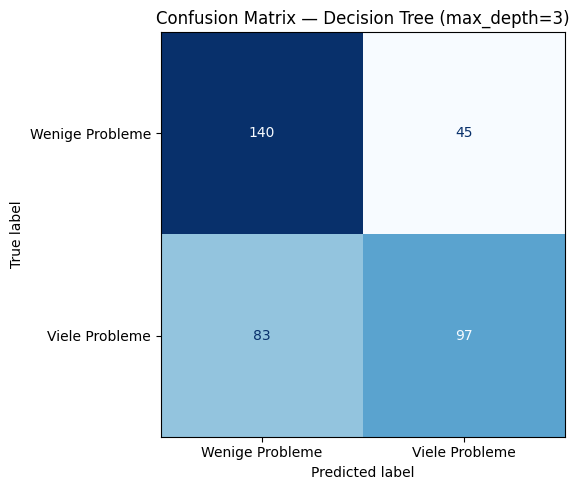

Grafik gespeichert: grafiken/confusion_matrix.png


In [5]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=ergebnis['cm'],
    display_labels=['Wenige Probleme', 'Viele Probleme']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Decision Tree (max_depth=3)', fontsize=12)
plt.tight_layout()
plt.savefig('grafiken/confusion_matrix.png', dpi=120)
plt.show()
print('Grafik gespeichert: grafiken/confusion_matrix.png')

---
## 4️⃣ Entscheidungsbaum visualisieren

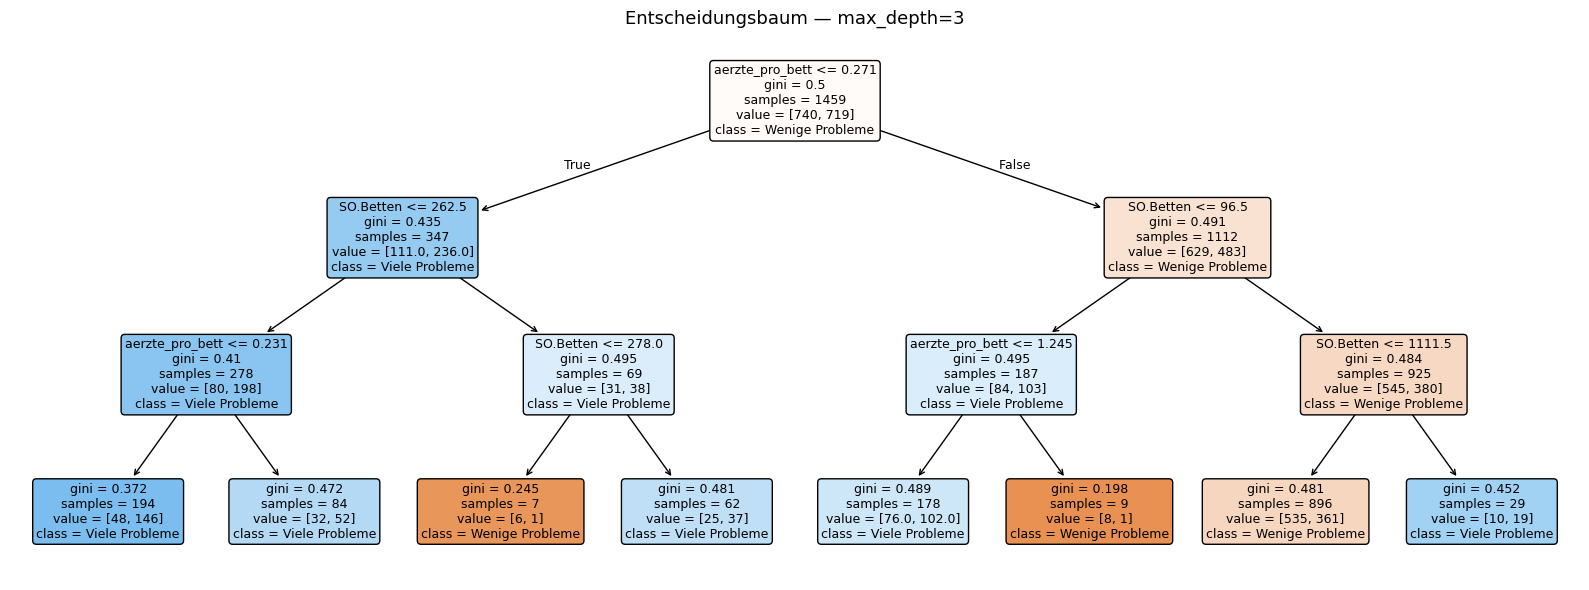

Grafik gespeichert: grafiken/decision_tree.png


In [6]:
fig, ax = plt.subplots(figsize=(16, 6))
plot_tree(
    modell.model,
    feature_names=modell.feature_names,
    class_names=['Wenige Probleme', 'Viele Probleme'],
    filled=True, rounded=True, fontsize=9, ax=ax
)
ax.set_title('Entscheidungsbaum — max_depth=3', fontsize=13)
plt.tight_layout()
plt.savefig('grafiken/decision_tree.png', dpi=120)
plt.show()
print('Grafik gespeichert: grafiken/decision_tree.png')

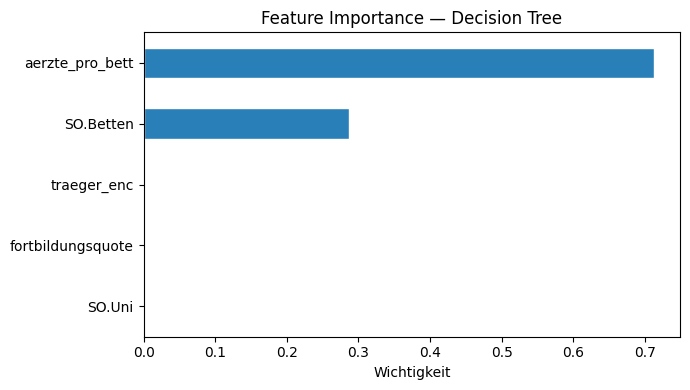


Feature Importance:
  aerzte_pro_bett          : 0.7133
  SO.Betten                : 0.2867
  SO.Uni                   : 0.0000
  fortbildungsquote        : 0.0000
  traeger_enc              : 0.0000


In [7]:
# Feature Importance
importance = pd.Series(
    modell.model.feature_importances_,
    index=modell.feature_names
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importance.plot(kind='barh', ax=ax, color='#2980b9', edgecolor='white')
ax.set_title('Feature Importance — Decision Tree', fontsize=12)
ax.set_xlabel('Wichtigkeit')
plt.tight_layout()
plt.savefig('grafiken/feature_importance.png', dpi=120)
plt.show()

print('\nFeature Importance:')
for feat, imp in importance.sort_values(ascending=False).items():
    print(f'  {feat:25s}: {imp:.4f}')

---
## 5️⃣ R²-Metrik — Lineare Regression zum Vergleich

In [8]:
# R² erklaert: wie viel Varianz der Ziel-Variable erklaert das Modell?
# Wert 0 = kein Erklarungswert, 1 = perfekte Vorhersage
# Fuer Klassifikation: Decision Tree Accuracy ist das Pendant zu R²

# Lineare Regression auf auffaellig_quote (kontinuierlich) -> R² zeigen
lr = LinearRegression()
lr.fit(X_train, y_train)  # y_train ist 0/1, aber LR funktioniert auch
y_pred_lr = lr.predict(X_test)
r2 = r2_score(y_test, y_pred_lr)

# Besser: R² auf der kontinuierlichen auffaellig_quote
X2, y2 = modell.prepare(df)
y_cont = df['auffaellig_quote']  # kontinuierliche Zielvariable
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y_cont, test_size=0.2, random_state=42)
lr2 = LinearRegression().fit(X2_train, y2_train)
r2_cont = r2_score(y2_test, lr2.predict(X2_test))

print('── R²-Metrik (Bestimmtheitsmaß) ──')
print(f'  R² (Lineare Regression auf Ziel-Variable 0/1):  {r2:.4f}')
print(f'  R² (Lineare Regression auf auffaellig_quote):   {r2_cont:.4f}')
print()
print('Interpretation:')
print(f'  R² = {r2_cont:.2f} bedeutet: Das Modell erklaert nur {r2_cont*100:.1f}% der Varianz.')
print('  Das bestaetigt den Befund der deskriptiven Analyse:')
print('  Strukturmerkmale erklaeren die Auffaelligkeit nur sehr schwach.')
print('  → Kein Zusammenhang ist ein valides Ergebnis!')

# Koeffizienten
print('\nLineare Regression Koeffizienten (auffaellig_quote):')
for feat, coef in zip(modell.feature_names, lr2.coef_):
    print(f'  {feat:25s}: {coef:+.5f}')
print(f'  Intercept: {lr2.intercept_:.4f}')

── R²-Metrik (Bestimmtheitsmaß) ──
  R² (Lineare Regression auf Ziel-Variable 0/1):  0.0161
  R² (Lineare Regression auf auffaellig_quote):   0.0229

Interpretation:
  R² = 0.02 bedeutet: Das Modell erklaert nur 2.3% der Varianz.
  Das bestaetigt den Befund der deskriptiven Analyse:
  Strukturmerkmale erklaeren die Auffaelligkeit nur sehr schwach.
  → Kein Zusammenhang ist ein valides Ergebnis!

Lineare Regression Koeffizienten (auffaellig_quote):
  SO.Betten                : -0.00003
  SO.Uni                   : -0.00730
  fortbildungsquote        : -0.02373
  aerzte_pro_bett          : -0.08663
  traeger_enc              : +0.00286
  Intercept: 0.8181


---
## 6️⃣ Modell speichern & laden (joblib)

In [9]:
# Modell speichern
modell.save('modell_krankenhaus.pkl')

# Modell laden und Probe-Vorhersage
geladenes_modell = KrankenhausModell.load('modell_krankenhaus.pkl')

# Beispiel: Ein Krankenhaus mit bestimmten Merkmalen
beispiel = pd.DataFrame([{
    'SO.Betten': 300, 'SO.Uni': 0,
    'fortbildungsquote': 0.8, 'aerzte_pro_bett': 0.4,
    'traeger_enc': 0  # privat
}])
vorhersage = geladenes_modell.model.predict(beispiel)[0]
proba = geladenes_modell.model.predict_proba(beispiel)[0]

print(f'Beispiel-Vorhersage: {"Viele Probleme" if vorhersage==1 else "Wenige Probleme"}')
print(f'Wahrscheinlichkeit:  Wenige={proba[0]:.2%}  |  Viele={proba[1]:.2%}')
print(f'\nModell geladen und einsatzbereit ✓')

Modell gespeichert: modell_krankenhaus.pkl
Beispiel-Vorhersage: Wenige Probleme
Wahrscheinlichkeit:  Wenige=59.71%  |  Viele=40.29%

Modell geladen und einsatzbereit ✓


---
## 7️⃣ Zusammenfassung Baustein 4

| Metrik | Wert | Interpretation |
|--------|------|----------------|
| Accuracy | siehe oben | Anteil korrekt klassifizierter Häuser |
| Precision | siehe oben | Wie verlässlich ist eine 'Viele Probleme'-Vorhersage? |
| Recall | siehe oben | Wie viele echte Problemhäuser werden erkannt? |
| F1-Score | siehe oben | Harmonsches Mittel aus Precision & Recall |
| R² | sehr niedrig | Strukturmerkmale erklären Qualitätsprobleme kaum |

> ⚠️ **Kein Zusammenhang ist ein valides Ergebnis.** Ein niedriger R²-Wert bestätigt die Befunde aus Baustein 2.